In [1]:
#THIS IS FOR DECONTAM  BUILDING ALPHA DIVERSITY METRICS FOR PLOTTING
#raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)
#D_alpha_df = pd.DataFrame(records)
#D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)

import pandas as pd
import numpy as np

# ============================
# LOAD WITH NO HEADER
# ============================
raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)

# Row 0 = anatomy
anatomy_row = raw.iloc[0]

# Row 1 = actual column names
header = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header

# Reset index cleanly
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY COLUMNS
# ============================
zotu_col = df.columns[0]
taxonomy_cols = df.columns[-7:]
sample_cols = df.columns[1:-7]

# ============================
# BUILD ANATOMY MAP
# ============================
anatomy_map = {
    sample_cols[i]: anatomy_row[i+1]
    for i in range(len(sample_cols))
}

# ============================
# NUMERIC CONVERSION
# ============================
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0,0,0,0
    N = counts.sum()
    p = counts / N
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon/np.log(richness) if richness>1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite Flat"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

def simplify_anatomy(a):
    if pd.isna(a): return "Unknown"
    a = str(a).lower()
    if "stoss" in a: return "Stoss"
    if "lee" in a: return "Lee"
    if "interdune" in a: return "Interdune"
    return "Other"

# ============================
# ALPHA DIVERSITY
# ============================
records = []

for sample in sample_cols:
    counts = df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)

    records.append({
        "Sample": sample,
        "Field": get_field(sample),
        "Anatomy": simplify_anatomy(anatomy_map[sample]),
        "Shannon": shannon,
        "Simpson": simpson,
        "Evenness": evenness,
        "Richness": richness
    })

D_alpha_df = pd.DataFrame(records)
D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)
print("Alpha diversity saved")


Alpha diversity saved


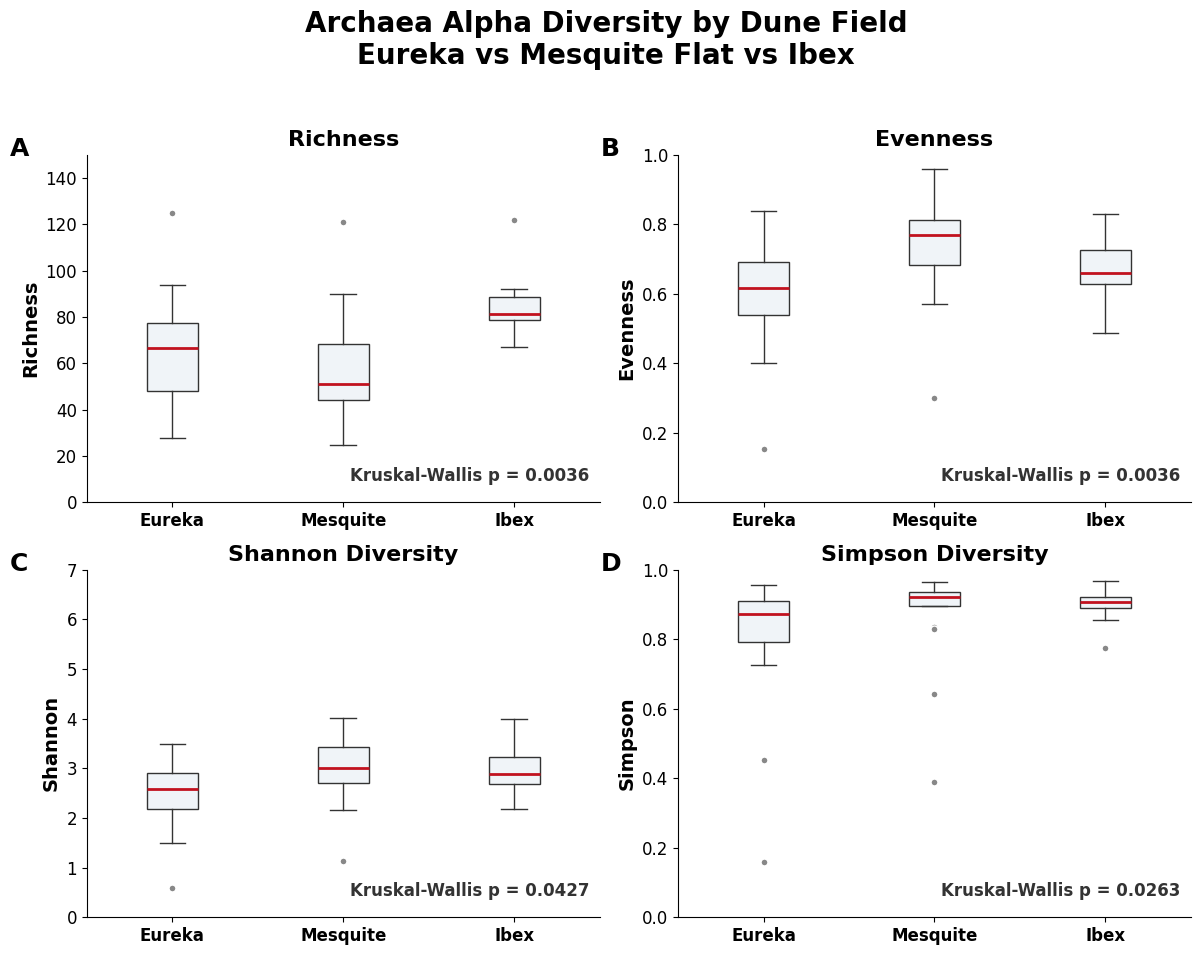

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# FILTER TO ARCHAEA
# ============================
archaea_df = df[df["Domain"].str.lower() == "archaea"]

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

# ============================
# BUILD ALPHA TABLE
# ============================
records = []
for sample in sample_cols:
    counts = archaea_df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)
    records.append({
        "Sample":   sample,
        "Field":    get_field(sample),
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
        "Richness": richness
    })

alpha_archaea = pd.DataFrame(records)

# ============================
# SAFE KRUSKAL-WALLIS
# ============================
def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

# ============================
# GROUPS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y1 = [alpha_archaea[alpha_archaea["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_archaea[alpha_archaea["Field"] == f]["Simpson"]  for f in x]
y3 = [alpha_archaea[alpha_archaea["Field"] == f]["Evenness"] for f in x]
y4 = [alpha_archaea[alpha_archaea["Field"] == f]["Richness"] for f in x]

p_shannon = safe_kruskal(y1)
p_simpson = safe_kruskal(y2)
p_even    = safe_kruskal(y3)
p_rich    = safe_kruskal(y4)

# ============================
# FIGURE
# order: Richness (A), Evenness (B), Shannon (C), Simpson (D)
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Archaea Alpha Diversity by Dune Field\n"
    "Eureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    #panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (0, 150))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [4]:
pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 88.0 MB/s eta 0:00:00


In [6]:
pip install scikit-posthocs

In [8]:
#GET TRANSECT DIFFERENCES FROM CSV
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "/content/DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

Archaeal ZOTUs: 349
Samples for analysis: 52

Samples per field:
Field
Eureka      24
Mesquite    18
Ibex        10

Samples per morphology:
Morph
Stoss        20
Lee          20
Interdune    12

ARCHAEAL ALPHA DIVERSITY BY MORPHOLOGY

Richness: KW p = 0.3900 ns

Evenness: KW p = 0.4785 ns

Shannon: KW p = 0.7152 ns

Simpson: KW p = 0.8528 ns


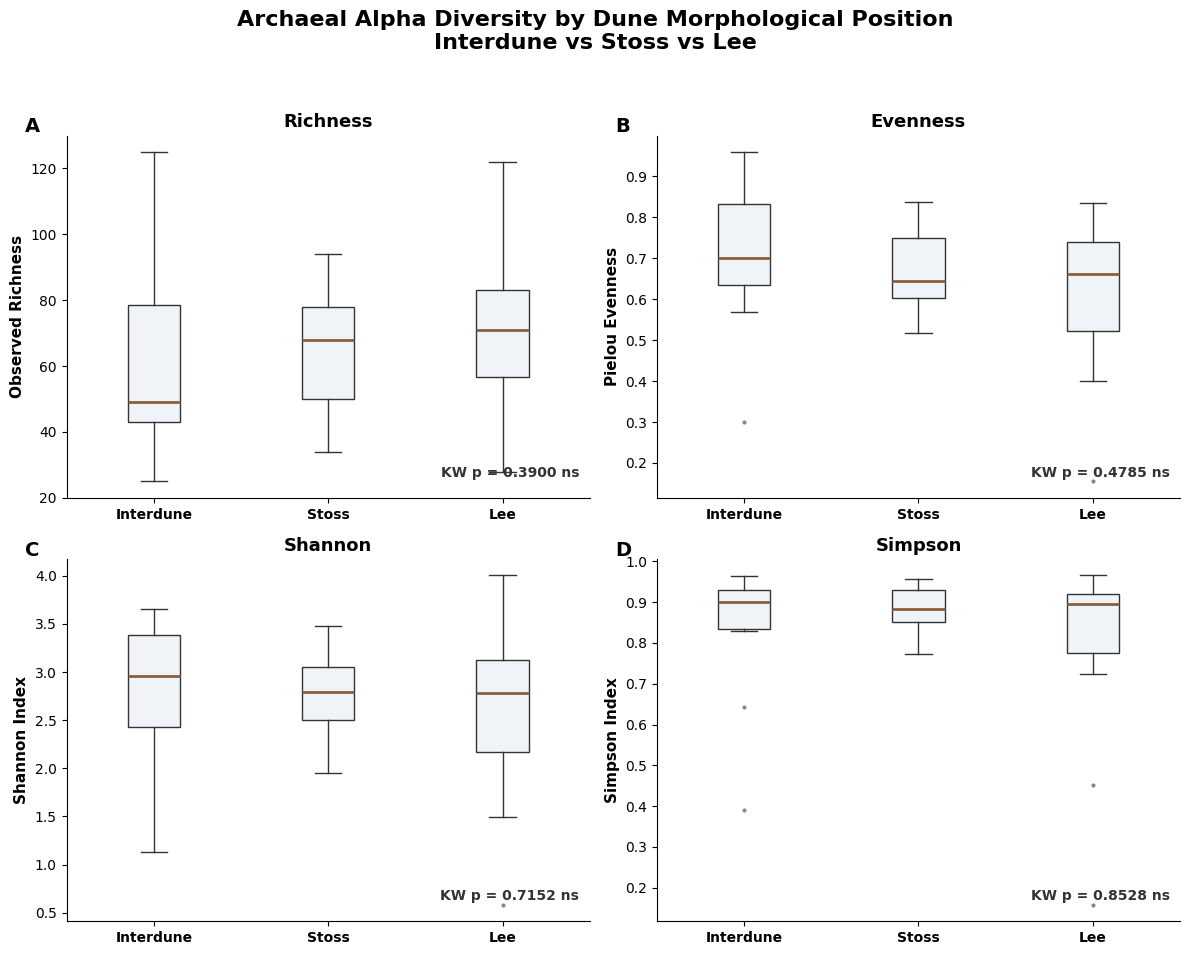


ARCHAEAL ALPHA DIVERSITY ALONG TRANSECT


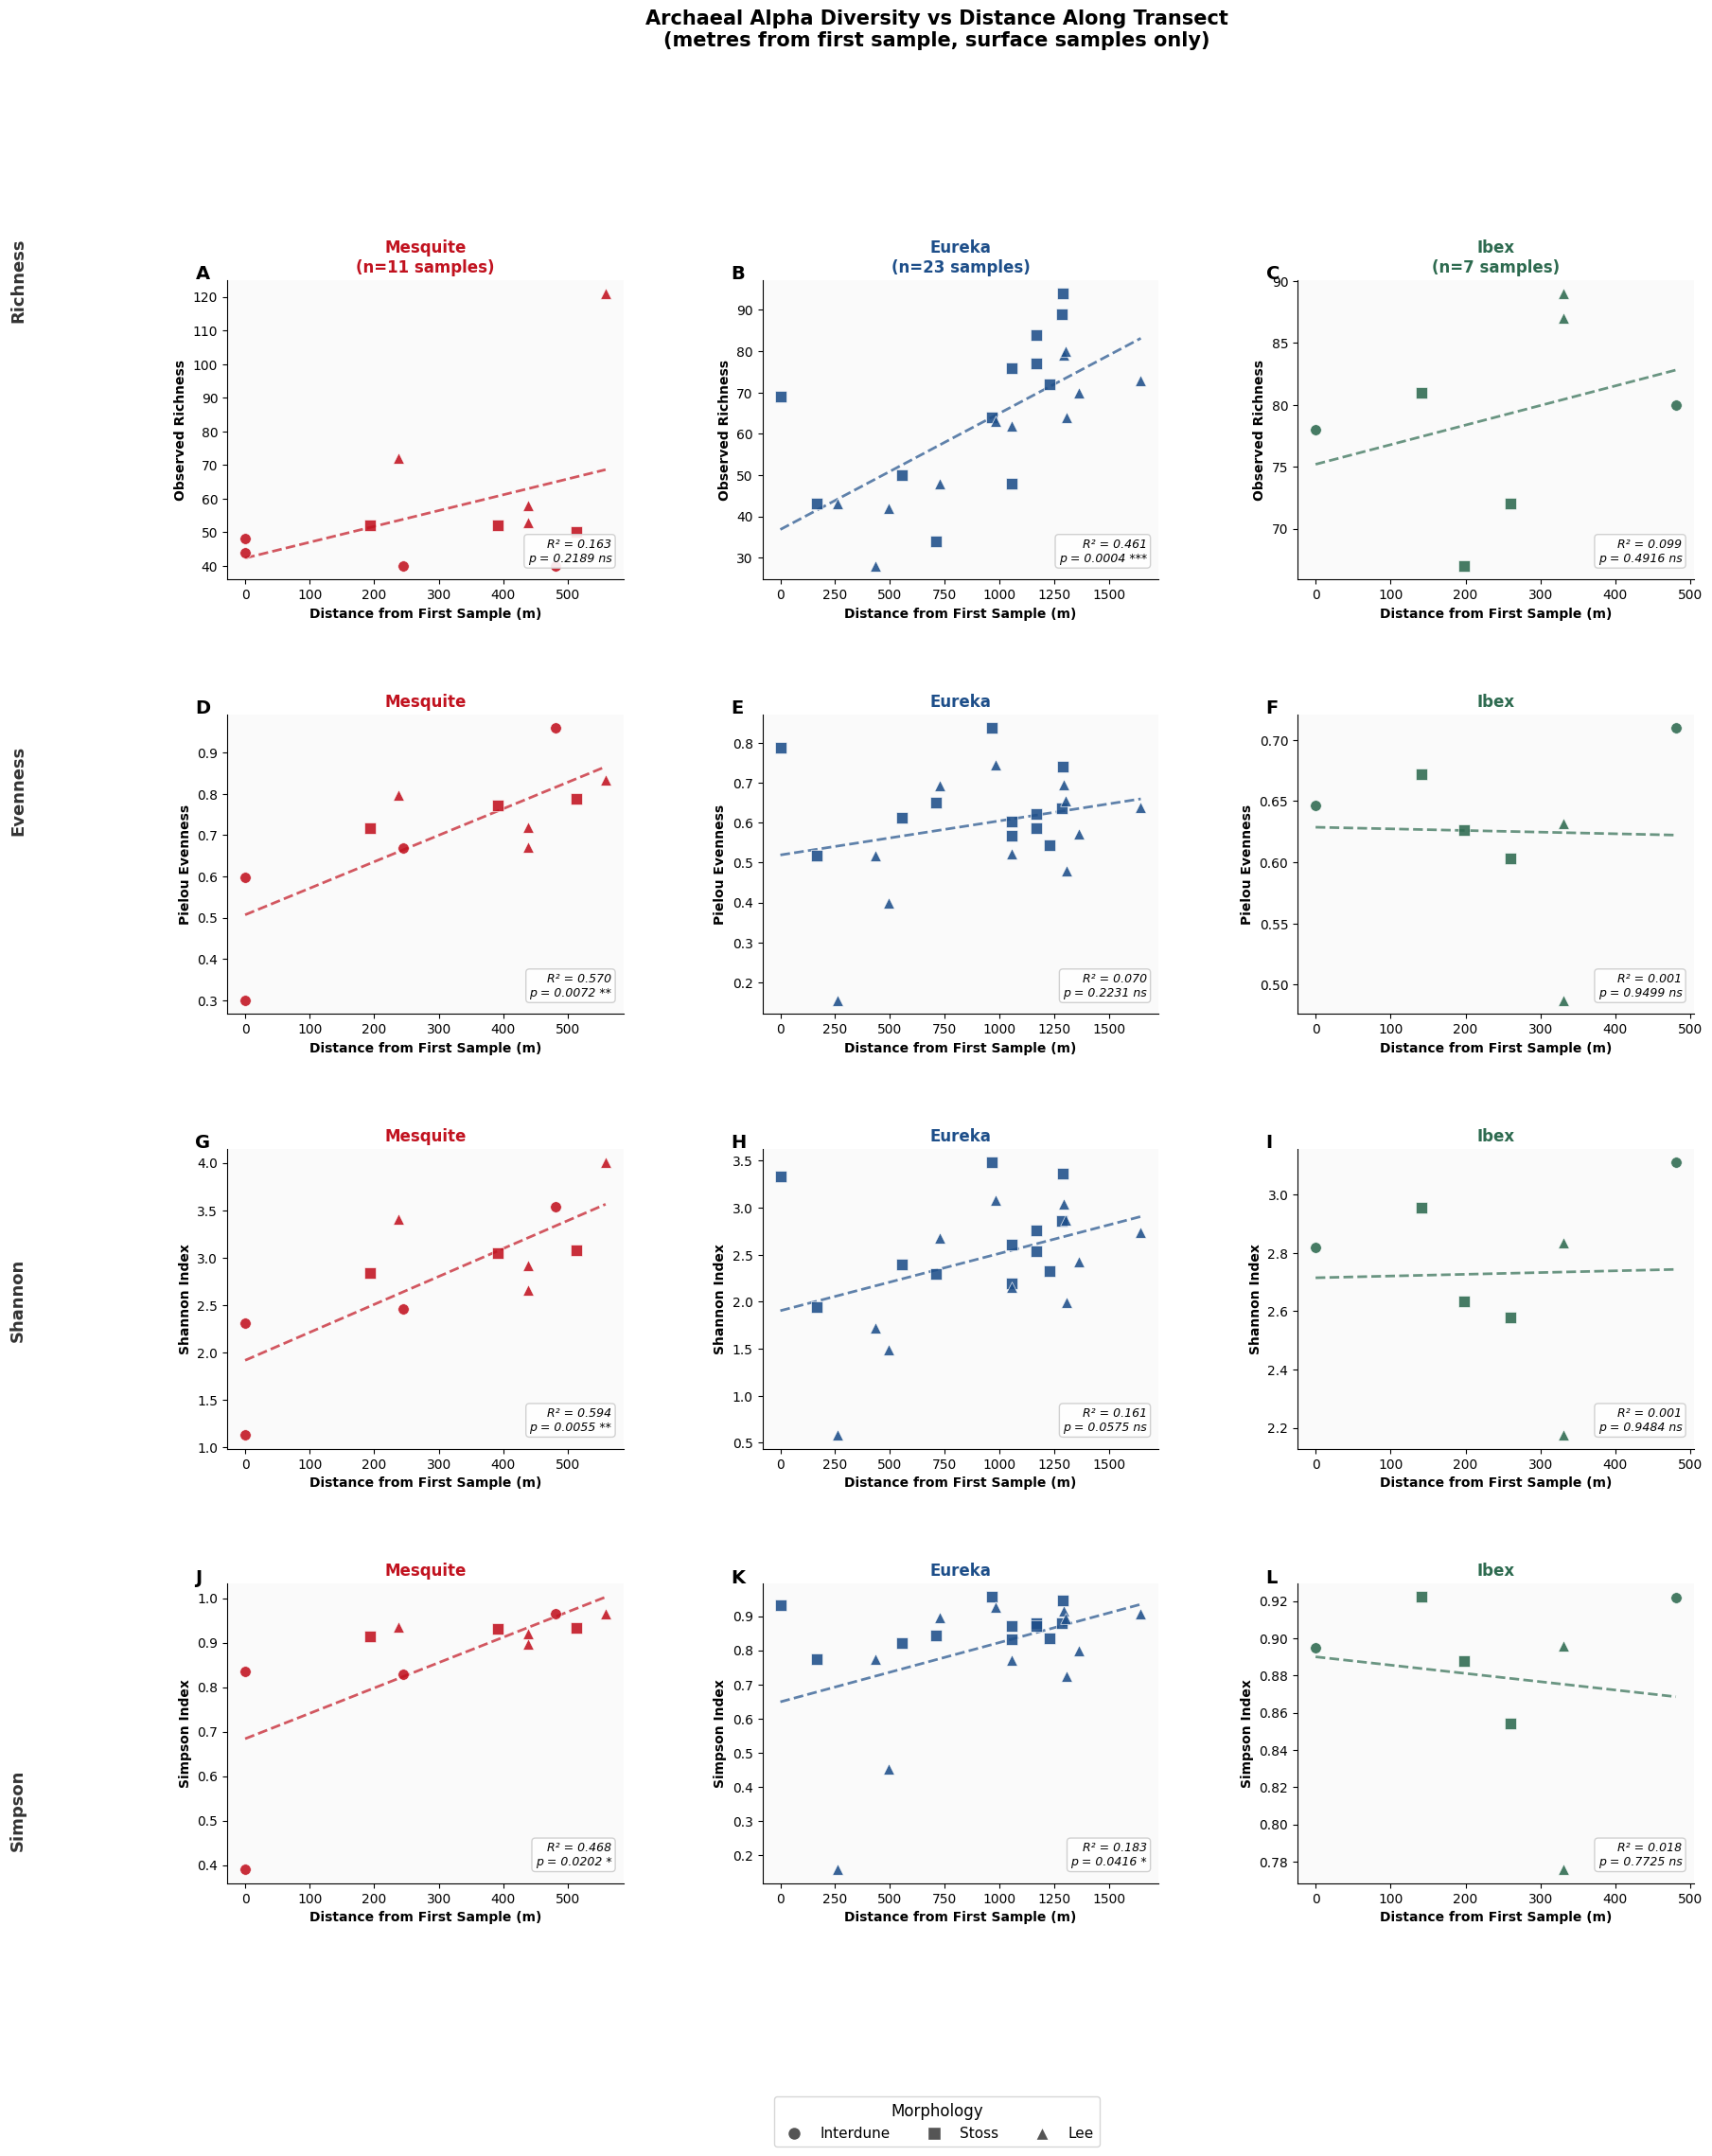


ARCHAEAL BETA DIVERSITY BY MORPHOLOGY
Archaeal OTU matrix: (52, 349)

Running PERMANOVA for morphology...
  PERMANOVA p = 0.0010  **
Running PERMDISP for morphology...
  PERMDISP  p = 0.5590  ns

ARCHAEAL BETA DIVERSITY ALONG TRANSECT — MANTEL

Mesquite (n=11)
  Mantel r=0.431  p=0.0120  *

Eureka (n=23)
  Mantel r=0.391  p=0.0020  **

Ibex (n=7)
  Mantel r=0.116  p=0.6990  ns


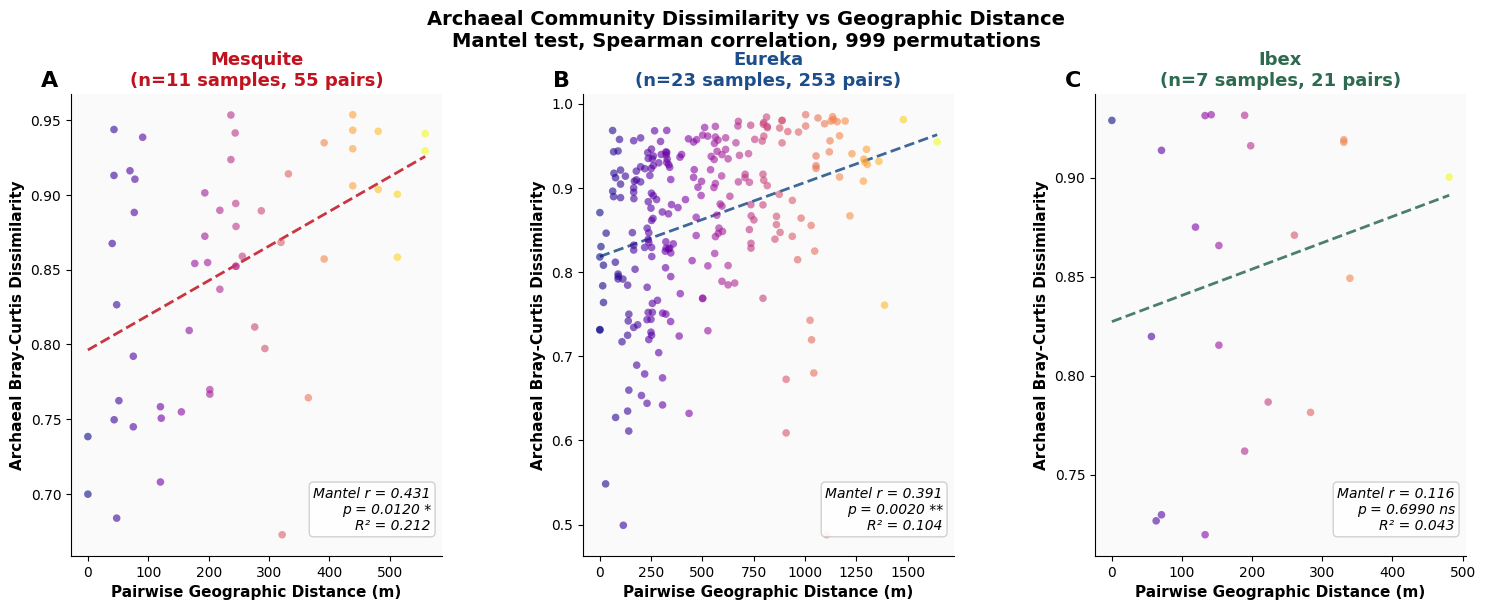

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy.stats import kruskal, linregress
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

# ============================
# LOAD COUNT FILE
# for alpha diversity
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()

# ============================
# FILTER ARCHAEA ONLY
# ============================
archaea = df[df["Domain"] == "archaea"].copy()
print(f"Archaeal ZOTUs: {len(archaea)}")

# ============================
# ANATOMY MAP
# ============================
col_list    = list(df.columns)
anatomy_map = {}
for s in sample_cols:
    try:
        col_idx        = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

# ============================
# MORPH SIMPLIFICATION
# map compound types to base position
# ============================
def simplify_morph(anat):
    anat = str(anat).strip()
    if "Depth" in anat:
        return None  # exclude depth samples
    if "Stoss" in anat: return "Stoss"
    if "Lee"   in anat: return "Lee"
    return "Interdune"

# ============================
# FIELD AND MORPH ASSIGNMENT
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

# ============================
# ALPHA DIVERSITY FUNCTIONS
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

# ============================
# BUILD ALPHA TABLE — ARCHAEA
# ============================
records = []
for s in sample_cols:
    morph = simplify_morph(anatomy_map.get(s, "Interdune"))
    if morph is None:
        continue  # skip depth samples
    counts                           = archaea[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Field":    get_field(s),
        "Morph":    morph,
        "Richness": rich,
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
    })

alpha_arch = pd.DataFrame(records)
print(f"Samples for analysis: {len(alpha_arch)}")
print(f"\nSamples per field:")
print(alpha_arch["Field"].value_counts().to_string())
print(f"\nSamples per morphology:")
print(alpha_arch["Morph"].value_counts().to_string())

# ============================
# SAFE KRUSKAL + DUNN
# ============================
def safe_kruskal(groups):
    valid = [g for g in groups if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

def run_dunn(metric_vals, group_labels, group_names, kw_p):
    if kw_p >= 0.05:
        return None
    combined = pd.DataFrame({
        "value": [float(v) for v in metric_vals],
        "group": group_labels
    })
    return sp.posthoc_dunn(
        combined, val_col="value",
        group_col="group", p_adjust="fdr_bh")

def sig_str(p):
    try:
        p = float(p)
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"
    except:
        return ""

# ============================
# BOX PLOT FUNCTION
# ============================
def make_boxplot(ax, groups_data, group_names, metric,
                 ylabel, panel_label, color, kw_p,
                 dunn_result=None):

    ax.boxplot(
        groups_data,
        tick_labels=group_names,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color=color, linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=4, linestyle="none",
                        markeredgecolor="white")
    )

    ax.text(-0.08, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")

    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=10)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    p_text = f"{kw_p:.4f}" if not np.isnan(kw_p) else "N/A"
    ax.text(0.98, 0.05,
            f"KW p = {p_text} {sig_str(kw_p)}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10, fontweight="bold",
            color="#333333")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# SECTION 1 — ALPHA DIVERSITY BY MORPHOLOGY
# ============================================================
print("\n" + "="*55)
print("ARCHAEAL ALPHA DIVERSITY BY MORPHOLOGY")
print("="*55)

morphs    = ["Interdune", "Stoss", "Lee"]
metrics   = ["Richness", "Evenness", "Shannon", "Simpson"]
ylabels   = ["Observed Richness", "Pielou Evenness",
             "Shannon Index", "Simpson Index"]

fig1, axs1 = plt.subplots(2, 2, figsize=(12, 10))
fig1.patch.set_facecolor("white")
fig1.suptitle(
    "Archaeal Alpha Diversity by Dune Morphological Position\n"
    "Interdune vs Stoss vs Lee",
    fontsize=16, fontweight="bold")

panel_labels = "ABCD"
color        = "#8B5E3C"

morph_groups = {}
for mi, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    ax = axs1[mi//2, mi%2]

    groups_data = [
        alpha_arch[alpha_arch["Morph"] == m][metric].dropna()
        for m in morphs
    ]
    kw_p = safe_kruskal(groups_data)

    all_vals   = [float(v) for g in groups_data for v in g]
    all_labels = [m for m, g in zip(morphs, groups_data)
                  for _ in g]
    dunn = run_dunn(all_vals, all_labels, morphs, kw_p)

    print(f"\n{metric}: KW p = {kw_p:.4f} {sig_str(kw_p)}")
    if dunn is not None:
        for m1, m2 in [("Interdune","Stoss"),
                        ("Interdune","Lee"),
                        ("Stoss","Lee")]:
            p = dunn.loc[m1, m2]
            print(f"  {m1} vs {m2}: p_adj={p:.4f} {sig_str(p)}")

    make_boxplot(ax, groups_data, morphs, metric,
                 ylabel, panel_labels[mi], color, kw_p, dunn)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

# ============================================================
# SECTION 2 — ALPHA DIVERSITY ALONG TRANSECT
# ============================================================
print("\n" + "="*55)
print("ARCHAEAL ALPHA DIVERSITY ALONG TRANSECT")
print("="*55)

transects = {
    "Mesquite": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite": "#c1121f",
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f"
}

MORPH_STYLE = {
    "Interdune": ("o", 70),
    "Stoss":     ("s", 65),
    "Lee":       ("^", 70),
}

fig2, axes2 = plt.subplots(
    4, 3, figsize=(20, 22),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig2.patch.set_facecolor("white")

panel_labels_t = "ABCDEFGHIJKL"
panel_idx      = 0

field_names = list(transects.keys())

for mi, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    for fi, field in enumerate(field_names):
        ax    = axes2[mi, fi]
        color = field_colors[field]

        slist = transects[field]
        valid = [s for s in slist
                 if s in coord_map
                 and s in alpha_arch["Sample"].values]

        if len(valid) == 0:
            ax.set_title(f"{field}\n(no data)",
                         fontsize=11, color=color)
            panel_idx += 1
            continue

        anchor_lat = coord_map[valid[0]]["Lat"]
        anchor_lon = coord_map[valid[0]]["Lon"]

        distances = []
        values    = []
        morphs_s  = []

        for s in valid:
            lat  = coord_map[s]["Lat"]
            lon  = coord_map[s]["Lon"]
            dist = haversine_m(anchor_lat, anchor_lon,
                               lat, lon)
            val  = alpha_arch.loc[
                alpha_arch["Sample"] == s, metric]
            if len(val) == 0:
                continue
            distances.append(dist)
            values.append(float(val.values[0]))
            morphs_s.append(
                simplify_morph(anatomy_map.get(s, "Interdune"))
                or "Interdune")

        if len(distances) < 3:
            ax.set_title(f"{field}\n(insufficient data)",
                         fontsize=11, color=color)
            panel_idx += 1
            continue

        for d, v, m in zip(distances, values, morphs_s):
            mk, sz = MORPH_STYLE.get(m, ("o", 70))
            ax.scatter(d, v, color=color,
                       marker=mk, s=sz,
                       edgecolors="white", linewidths=0.5,
                       alpha=0.88, zorder=3)

        slope, intercept, r_val, p_val, _ = linregress(
            distances, values)
        r2   = r_val ** 2
        x_ln = np.linspace(min(distances),
                            max(distances), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.7)

        sig = sig_str(p_val)
        ax.text(0.97, 0.05,
                f"R² = {r2:.3f}\n"
                f"p = {p_val:.4f} {sig}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=9, style="italic",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white",
                          edgecolor="#cccccc",
                          alpha=0.9))

        ax.text(-0.08, 1.05,
                panel_labels_t[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        title = f"{field}" if mi > 0 else \
                f"{field}\n(n={len(distances)} samples)"
        ax.set_title(title, fontsize=12,
                     fontweight="bold", color=color)
        ax.set_xlabel("Distance from First Sample (m)",
                      fontsize=10, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=10,
                      fontweight="bold")
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp_ in ["top", "right"]:
            ax.spines[sp_].set_visible(False)

        panel_idx += 1

row_labels = ["Richness", "Evenness", "Shannon", "Simpson"]
for mi, label in enumerate(row_labels):
    fig2.text(0.01, 0.88 - mi * 0.245, label,
              fontsize=13, fontweight="bold",
              va="center", rotation=90, color="#333333")

morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Lee"),
]
fig2.legend(handles=morph_handles, title="Morphology",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=3, fontsize=11, title_fontsize=12,
            frameon=True, edgecolor="#cccccc")

fig2.suptitle(
    "Archaeal Alpha Diversity vs Distance Along Transect\n"
    "(metres from first sample, surface samples only)",
    fontsize=15, fontweight="bold", y=1.01)

plt.show()

# ============================================================
# SECTION 3 — BETA DIVERSITY BY MORPHOLOGY
# ============================================================
print("\n" + "="*55)
print("ARCHAEAL BETA DIVERSITY BY MORPHOLOGY")
print("="*55)

# load relabund for beta diversity
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_r    = pd.read_csv(rel_path, header=None)
df_r     = raw_r.iloc[2:].copy()
df_r.columns = raw_r.iloc[1]
df_r.reset_index(drop=True, inplace=True)

df_r[sample_cols] = df_r[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_r["Domain"] = df_r["Domain"].str.lower().str.strip()

arch_r = df_r[df_r["Domain"] == "archaea"].copy()

# surface samples only — exclude depth
surface_samples = [
    s for s in sample_cols
    if simplify_morph(anatomy_map.get(s, "Interdune"))
    is not None
]

otu_arch = (
    arch_r.set_index(arch_r.columns[0])[surface_samples]
    .T.fillna(0)
)
otu_arch.index.name   = None
otu_arch.columns.name = None

print(f"Archaeal OTU matrix: {otu_arch.shape}")

# bray-curtis
bc_arr = squareform(pdist(
    otu_arch.values.astype(float),
    metric="braycurtis"))
dm_bc  = DistanceMatrix(bc_arr, ids=list(otu_arch.index))

# morphology groups
morph_labels = [
    simplify_morph(anatomy_map.get(s, "Interdune"))
    for s in otu_arch.index
]

from skbio.stats.distance import permanova, permdisp

morph_series = pd.Series(morph_labels,
                          index=otu_arch.index,
                          name="Morph")

print("\nRunning PERMANOVA for morphology...")
res_perm = permanova(dm_bc, morph_series, permutations=999)
print(f"  PERMANOVA p = {res_perm['p-value']:.4f}  "
      f"{sig_str(res_perm['p-value'])}")

print("Running PERMDISP for morphology...")
try:
    res_disp = permdisp(dm_bc, morph_series, permutations=999)
    print(f"  PERMDISP  p = {res_disp['p-value']:.4f}  "
          f"{sig_str(res_disp['p-value'])}")
except Exception as e:
    print(f"  PERMDISP error: {e}")

# ============================================================
# SECTION 4 — BETA DIVERSITY ALONG TRANSECT (MANTEL)
# ============================================================
print("\n" + "="*55)
print("ARCHAEAL BETA DIVERSITY ALONG TRANSECT — MANTEL")
print("="*55)

fig3, axes3 = plt.subplots(
    1, 3, figsize=(18, 6),
    gridspec_kw={"wspace": 0.38})
fig3.patch.set_facecolor("white")

panel_labels_m = "ABC"

for ax, field, panel_lbl in zip(
        axes3, field_names, panel_labels_m):

    color = field_colors[field]
    slist = transects[field]
    samps = [s for s in slist
             if s in otu_arch.index and s in coord_map]
    n     = len(samps)

    print(f"\n{field} (n={n})")

    if n < 4:
        ax.set_title(f"{field}\n(n={n} — insufficient)",
                     color=color, fontsize=12,
                     fontweight="bold")
        panel_idx += 1
        continue

    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                geo_mat[i,j] = haversine_m(
                    coord_map[samps[i]]["Lat"],
                    coord_map[samps[i]]["Lon"],
                    coord_map[samps[j]]["Lat"],
                    coord_map[samps[j]]["Lon"])

    sub    = otu_arch.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    ids    = list(range(n))
    r, p, _ = mantel(
        DistanceMatrix(geo_mat, ids=ids),
        DistanceMatrix(bc_mat,  ids=ids),
        method="spearman", permutations=999)

    sig = sig_str(p)
    print(f"  Mantel r={r:.3f}  p={p:.4f}  {sig}")

    idx   = np.triu_indices(n, k=1)
    x     = geo_mat[idx]
    y     = bc_mat[idx]

    ax.scatter(x, y, c=x, cmap="plasma",
               alpha=0.6, s=30, linewidths=0,
               vmin=x.min(), vmax=x.max(), zorder=3)

    slope, intercept, r_val, p_val, _ = linregress(x, y)
    r2   = r_val ** 2
    x_ln = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_ln, slope * x_ln + intercept,
            color=color, linewidth=2,
            linestyle="--", alpha=0.85)

    ax.text(0.97, 0.05,
            f"Mantel r = {r:.3f}\n"
            f"p = {p:.4f} {sig}\n"
            f"R² = {r2:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
    ax.set_title(f"{field}\n(n={n} samples, "
                 f"{len(x)} pairs)",
                 fontsize=13, fontweight="bold",
                 color=color)
    ax.set_xlabel("Pairwise Geographic Distance (m)",
                  fontsize=11, fontweight="bold")
    ax.set_ylabel("Archaeal Bray-Curtis Dissimilarity",
                  fontsize=11, fontweight="bold")
    ax.set_facecolor("#fafafa")
    for sp_ in ["top", "right"]:
        ax.spines[sp_].set_visible(False)

fig3.suptitle(
    "Archaeal Community Dissimilarity vs Geographic Distance\n"
    "Mantel test, Spearman correlation, 999 permutations",
    fontsize=14, fontweight="bold", y=1.02)
plt.show()
